In [2]:
# Set up sys.path so that 'src/spindle_dev' is importable as 'spindle_dev'
import sys
import importlib
from pathlib import Path

project_root = '/data/sarkar_lab/Projects/spindle_dev'
src_path = Path(project_root) / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import spindle_dev
# Reload to pick up code changes without restarting the kernel
importlib.reload(spindle_dev)

<module 'spindle_dev' from '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/__init__.py'>

In [3]:
save_figure = False

In [4]:
import scanpy as sc

In [7]:
prefix = "/home/NAShome/sarkah1/accre_transfer"
#adata = sc.read_h5ad(f"{prefix}/data/sarkar_lab/zenodo_data/2023_xenium_human_breast_cancer/adata.h5ad")
adata_path = f"{prefix}/data/sarkar_lab/zenodo_data/2023_xenium_human_breast_cancer/adata.h5ad"
adata = sc.read_h5ad(adata_path)

In [9]:
adata = adata[adata.obs.loc[adata.obs.Cluster != "Unlabeled"].index, :].copy()

/tmp/ipykernel_2203094/1942974121.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Cluster"], spot_size=13)


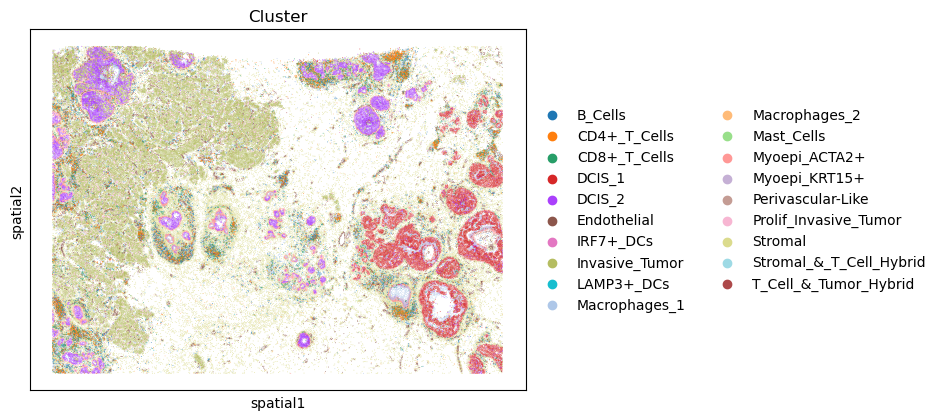

In [10]:
sc.pl.spatial(adata, color=["Cluster"], spot_size=13)

In [11]:
# Reload spindle_dev metrics, index, and package after code changes
import importlib
import spindle_dev
import spindle_dev.metrics as metrics
import spindle_dev.index as index
import spindle_dev.preprocessing as preprocessing
import spindle_dev.plotting as plotting

# Reload in dependency order so new symbols are available
importlib.reload(metrics)
importlib.reload(index)
importlib.reload(preprocessing)
importlib.reload(plotting)
importlib.reload(spindle_dev)
import spindle_dev.typing as typing
importlib.reload(typing)
import spindle_dev.test as test
import spindle_dev.search as search
importlib.reload(test)
importlib.reload(search)

<module 'spindle_dev.search' from '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/search.py'>

In [12]:
def prepare_to_index(adata, resolution=0.2, min_final_size=20):
    coords = adata.obsm["spatial"]
    tiles = preprocessing.build_quadtree_tiles(coords, max_pts=200, min_side=0.0, max_depth=40)
    num_genes = adata.n_vars
    genes_work, gene_idx = spindle_dev.preprocessing.topvar_genes(adata, G=num_genes)  
    tile_covs = spindle_dev.preprocessing.build_tile_covs_full(adata, tiles, gene_idx, n_jobs=8, eps=1e-6)
    data = index.ProcessedData(tiles, tile_covs, genes_work, adata.n_obs)
    data.reduce_dim(num_pca_components=30, n_components=2, do_umap=True)
    data.cluster_spds(cluster_distance="tree", cluster_method="leiden", resolution=resolution)
    data.assign_label_to_spots()
    data.get_corr_mean_by_cluster()
    out_dict = data.get_adaptive_runs(find_blocks=True, with_size_guard=True,min_final_size=min_final_size,max_final_size=100)
    return tiles, tile_covs, genes_work, data, out_dict

In [13]:
tiles, tile_covs, genes_work, data, out_dict = prepare_to_index(adata, min_final_size=15)

[2026-04-22 13:49:26,757] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-04-22 13:49:26,786] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
[2026-04-22 13:49:31,376] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-04-22 13:49:33,907] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-04-22 13:49:37,520] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.06878107 0.05380314 0.02646384 0.01915205 0.01300586 0.01025453
 0.00781812 0.00735731 0.00665263 0.00645236 0.00500298 0.00465103
 0.00423426 0.00416654 0.00382042 0.00364907 0.00355717 0.00348549
 0.00334294 0.00319313 0.00303316 0.00301945 0.00300855 0.00294676
 0.00288963 0.00281065 0.00275823 0.00274145 0.00271152 0.00265672]
[2026-04-22 13:49:37,522] INFO spindle_dev.index: Reducing latent features to 2 dimensions using UMAP.
/home/NAS/sarkah1/miniforge3/envs/spatial_cpu/lib/python3.12/site-p

In [14]:
import matplotlib.pylab as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

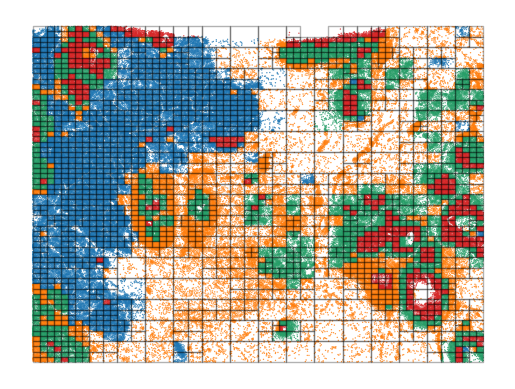

In [15]:
import numpy as np
palette = sc.pl.palettes.default_20
point_colors = [palette[lab] for lab in data.spot_label.values()]
labels = data.labels
indices = np.array([int(i) for i in data.spot_label.keys()])
coords = adata.obsm['spatial']
plt.scatter(coords[indices,0], coords[indices,1], s=1, c=point_colors, lw=0, alpha=0.8)
patches = []
for t in tiles:
    bbox = t.bbox if hasattr(t, "bbox") else t["bbox"]  # (xmin,ymin,xmax,ymax)
    x0, y0, x1, y1 = bbox
    patches.append(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))
pc = PatchCollection(patches, match_original=True, linewidths=0.2, edgecolors='b', alpha=0.3)
# add collection
ax = plt.gca()
ax.add_collection(pc)
ax.invert_yaxis()
ax.axis('off')
if save_figure:
    plt.savefig("/data/sarkar_lab/Projects/spindle_dev/results/hbreast_10X_wo_unlabeled/spatial_plot_with_cluster.png", dpi=300)
plt.show()

In [16]:
epsilon_block_wise_dict = {}
epsilon_dict = {}
for cluster_id in set(data.labels):
    eps_per_block, eps_elbow_per_block, eps = index.choose_adaptive_epsilons(data, cluster_id, k_target_per_block=64)
    epsilon_block_wise_dict[int(cluster_id)] = eps_elbow_per_block
    epsilon_dict[int(cluster_id)] = eps


config = typing.IndexConfig()
config.epsilon_dict = epsilon_dict
config.epsilon_block_wise_dict = epsilon_block_wise_dict
config.threshold_type = 'constant'
config.kmean_method = 'epsilon_net'

In [17]:
dag_dict, stats, dist_list = index.index_spds(
    data,
    config
)

[2026-04-22 13:58:50,634] INFO spindle_dev.index: Processing cluster 0
[2026-04-22 13:58:50,635] INFO spindle_dev.index: Building SPD index with epsilon=7.570320715323195
[2026-04-22 13:58:50,636] INFO spindle_dev.index: Step 1: Cluster blocks within each class of SPD matrices.
[2026-04-22 13:58:51,250] INFO spindle_dev.index: Cluster 0: 733 SPDs, 16 blocks
[2026-04-22 13:58:51,250] INFO spindle_dev.index:  Using epsilon-net clustering for block 0
[2026-04-22 13:58:51,343] INFO spindle_dev.index:  Finished block 0 in 0.09 seconds, found 2 clusters.
[2026-04-22 13:58:51,344] INFO spindle_dev.index:  Using epsilon-net clustering for block 1
[2026-04-22 13:58:51,400] INFO spindle_dev.index:  Finished block 1 in 0.06 seconds, found 5 clusters.
[2026-04-22 13:58:51,400] INFO spindle_dev.index:  Using epsilon-net clustering for block 2
[2026-04-22 13:58:51,464] INFO spindle_dev.index:  Finished block 2 in 0.06 seconds, found 6 clusters.
[2026-04-22 13:58:51,464] INFO spindle_dev.index:  Usin

In [ ]:

from spindle_dev.interval_index import (
    build_all_interval_indices,
    query_interval_index,
    summarize_interval_index,
    describe_intervals,
)


In [ ]:

# Patch the existing config to enable the interval index, then build it
config.use_interval_index = True
config.interval_mode = "dyadic"         # 'all' | 'dyadic' | 'fixed'
config.interval_max_layer_size = 64     # skip blocks larger than this
config.interval_max_iters = 5
# interval_eps = None → reuses per-niche epsilon from config.epsilon_dict

print("Building interval index...")
ivl_idx = build_all_interval_indices(data, config)
print("Done.\n")
summarize_interval_index(ivl_idx)


In [26]:
def perform_partial_search(cluster_id, block_index, interval, query_spd, data, ivl_idx, top_k=10):
    """Query the interval index using only a sub-block of a full SPD matrix.

    cluster_id  : niche to search within
    block_index : which block (layer) within the niche
    interval    : (a, b) half-open slice within the block's permuted genes
    query_spd   : full (unpermuted) SPD matrix for the query tile
    """
    perm = data.perm_list[cluster_id]
    block_runs = data.block_dict[cluster_id]
    block_start, block_end = block_runs[block_index]
    block_perm = perm[block_start:block_end]   # global gene indices for this block

    a, b = interval
    sub_perm = block_perm[a:b]                 # global gene indices for the interval

    q_sub = query_spd[np.ix_(sub_perm, sub_perm)]

    print(f"Niche {cluster_id}, Block {block_index} "
          f"(block genes {block_start}:{block_end}, size {block_end-block_start}), "
          f"Interval [{a},{b}) → sub-matrix {q_sub.shape}")

    results = query_interval_index(ivl_idx, cluster_id, block_index, interval, q_sub, top_k=top_k)

    if not results:
        print("  No results — block was skipped (too large) or interval not in dyadic set.")
        return results

    print(f"\nTop {len(results)} interval clusters:")
    for rank, (dist, members) in enumerate(results, 1):
        preview = members[:8]
        tail = f"... (+{len(members)-8})" if len(members) > 8 else ""
        print(f"  [{rank}] dist={dist:.4f}  spd_ids={preview}{tail}  ({len(members)} members)")

    return results


# --- Inspect available blocks for niche 0 ---
cluster_id = 0
block_runs = data.block_dict[cluster_id]
max_layer = getattr(config, "interval_max_layer_size", 64)

print(f"Niche {cluster_id} has {len(block_runs)} blocks:")
for bi, (s, e) in enumerate(block_runs):
    skipped = "  ← skipped (too large)" if (e - s) > max_layer else ""
    print(f"  block {bi:2d}: genes [{s:3d},{e:3d})  size {e-s:3d}{skipped}")


Niche 0 has 16 blocks:
  block  0: genes [  0, 26)  size  26
  block  1: genes [ 26, 41)  size  15
  block  2: genes [ 41, 56)  size  15
  block  3: genes [ 56, 71)  size  15
  block  4: genes [ 71, 86)  size  15
  block  5: genes [ 86,101)  size  15
  block  6: genes [101,121)  size  20
  block  7: genes [121,136)  size  15
  block  8: genes [136,151)  size  15
  block  9: genes [151,166)  size  15
  block 10: genes [166,184)  size  18
  block 11: genes [184,208)  size  24
  block 12: genes [208,232)  size  24
  block 13: genes [232,247)  size  15
  block 14: genes [247,262)  size  15
  block 15: genes [262,313)  size  51


In [27]:
# --- Pick a tile from the indexed set as query ---
# Use the first tile in niche 0 as a concrete example
cluster_id = 0
niche_indices = [i for i, lab in enumerate(data.labels) if int(lab) == cluster_id]
query_tile_local_idx = niche_indices[0]   # change this to try different tiles
query_spd = data.spd_matrices[query_tile_local_idx]

print(f"Using tile local_idx={query_tile_local_idx} (spd_id={data.spd_ids[query_tile_local_idx]}) from niche {cluster_id}")
print(f"SPD matrix shape: {query_spd.shape}\n")

# Show dyadic intervals available for block 0
block_index = 0
block_start, block_end = data.block_dict[cluster_id][block_index]
block_size = block_end - block_start
print(f"Dyadic intervals for block {block_index} (size {block_size}):")
describe_intervals(block_size, "dyadic")

# Run partial search with interval (0, 4)
interval = (0, 4)
results = perform_partial_search(cluster_id, block_index, interval, query_spd, data, ivl_idx, top_k=10)


Using tile local_idx=9 (spd_id=9) from niche 0
SPD matrix shape: (313, 313)

Dyadic intervals for block 0 (size 26):
Block size: 26  mode: dyadic  →  49 intervals

 len  [a, b)    coverage (gene positions 0–25)
 ---  ------    ──────────────────────────
   1  [ 0, 1)   █░░░░░░░░░░░░░░░░░░░░░░░░░
   1  [ 1, 2)   ░█░░░░░░░░░░░░░░░░░░░░░░░░
   1  [ 2, 3)   ░░█░░░░░░░░░░░░░░░░░░░░░░░
   1  [ 3, 4)   ░░░█░░░░░░░░░░░░░░░░░░░░░░
   1  [ 4, 5)   ░░░░█░░░░░░░░░░░░░░░░░░░░░
   1  [ 5, 6)   ░░░░░█░░░░░░░░░░░░░░░░░░░░
   1  [ 6, 7)   ░░░░░░█░░░░░░░░░░░░░░░░░░░
   1  [ 7, 8)   ░░░░░░░█░░░░░░░░░░░░░░░░░░
   1  [ 8, 9)   ░░░░░░░░█░░░░░░░░░░░░░░░░░
   1  [ 9,10)   ░░░░░░░░░█░░░░░░░░░░░░░░░░
   1  [10,11)   ░░░░░░░░░░█░░░░░░░░░░░░░░░
   1  [11,12)   ░░░░░░░░░░░█░░░░░░░░░░░░░░
   1  [12,13)   ░░░░░░░░░░░░█░░░░░░░░░░░░░
   1  [13,14)   ░░░░░░░░░░░░░█░░░░░░░░░░░░
   1  [14,15)   ░░░░░░░░░░░░░░█░░░░░░░░░░░
   1  [15,16)   ░░░░░░░░░░░░░░░█░░░░░░░░░░
   1  [16,17)   ░░░░░░░░░░░░░░░░█░░░░░░░░░
   1  [17,18)  

In [28]:
interval = (0, 4)
results = perform_partial_search(cluster_id, block_index, interval, query_spd, data, ivl_idx, top_k=10)


Niche 0, Block 0 (block genes 0:26, size 26), Interval [0,4) → sub-matrix (4, 4)

Top 10 interval clusters:
  [1] dist=0.3807  spd_ids=[9, 609, 623, 640, 658, 659, 662, 664]... (+60)  (68 members)
  [2] dist=4.5158  spd_ids=[827, 848, 1369, 1561, 1670, 1674, 1771, 1875]... (+2)  (10 members)
  [3] dist=4.6087  spd_ids=[1688]  (1 members)
  [4] dist=4.6677  spd_ids=[1568]  (1 members)
  [5] dist=4.7175  spd_ids=[1416]  (1 members)
  [6] dist=4.7567  spd_ids=[1690]  (1 members)
  [7] dist=4.9205  spd_ids=[632, 843, 871, 915, 963, 1331, 1367, 1427]... (+9)  (17 members)
  [8] dist=4.9719  spd_ids=[529, 530, 531, 532, 536, 539, 540, 542]... (+460)  (468 members)
  [9] dist=5.5794  spd_ids=[1407]  (1 members)
  [10] dist=5.5962  spd_ids=[1712]  (1 members)


In [30]:
# --- Sanity check: the query tile itself should appear in the top results ---
query_spd_id = data.spd_ids[query_tile_local_idx]
ivl_hits = {m for _, members in results for m in members}

if query_spd_id in ivl_hits:
    rank = next(r+1 for r, (_, members) in enumerate(results) if query_spd_id in members)
    print(f"PASS  query tile (spd_id={query_spd_id}) found at rank {rank}")
else:
    print(f"MISS  query tile (spd_id={query_spd_id}) not in top-{len(results)} interval results")
    print("      (expected for partial/sub-block queries — interval may be too small to uniquely identify the tile)")

print(f"\nTotal candidates returned: {len(ivl_hits)}")


PASS  query tile (spd_id=9) found at rank 1

Total candidates returned: 569


In [32]:
importlib.reload(spindle_dev.interval_index)

<module 'spindle_dev.interval_index' from '/home/NAShome/sarkah1/accre_transfer/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/interval_index.py'>

In [33]:
from spindle_dev.interval_index import decompose_to_dyadic, query_arbitrary_interval

# --- Arbitrary contiguous interval search via dyadic decomposition ---
# Any [a, b) is split into ≤ 2·log2(b-a) dyadic pieces; results are
# intersected across pieces and ranked by summed distance.

cluster_id = 0
block_index = 0
block_start, block_end = data.block_dict[cluster_id][block_index]
block_size = block_end - block_start

# Pick an arbitrary interval — does NOT have to be dyadic-aligned
a, b = 3, 11   # change freely; must satisfy 0 <= a < b <= block_size

pieces = decompose_to_dyadic(a, b)
print(f"Arbitrary interval [{a},{b}) decomposes into {len(pieces)} dyadic pieces: {pieces}\n")

# Extract the full permuted block sub-matrix for the query
perm = data.perm_list[cluster_id]
block_perm = perm[block_start:block_end]
q_block = query_spd[np.ix_(block_perm, block_perm)]   # (block_size, block_size)

results = query_arbitrary_interval(
    ivl_idx, cluster_id, block_index, a, b, q_block, top_k=10
)

if not results:
    print("No results — one or more dyadic pieces had no indexed candidates.")
else:
    print(f"Top {len(results)} candidates (sum of per-piece distances):")
    for rank, (dist, members) in enumerate(results, 1):
        print(f"  [{rank}] total_dist={dist:.4f}  spd_ids={members}")

# Sanity: query tile should appear near the top
query_spd_id = data.spd_ids[query_tile_local_idx]
found = any(query_spd_id in members for _, members in results)
print(f"\nQuery tile (spd_id={query_spd_id}) in results: {'PASS' if found else 'MISS'}")


Arbitrary interval [3,11) decomposes into 4 dyadic pieces: [(3, 4), (4, 8), (8, 10), (10, 11)]

Top 10 candidates (sum of per-piece distances):
  [1] total_dist=0.4700  spd_ids=[9]
  [2] total_dist=0.4700  spd_ids=[830]
  [3] total_dist=0.4700  spd_ids=[895]
  [4] total_dist=0.4700  spd_ids=[973]
  [5] total_dist=0.4700  spd_ids=[1416]
  [6] total_dist=0.4700  spd_ids=[1601]
  [7] total_dist=0.4700  spd_ids=[1690]
  [8] total_dist=0.4700  spd_ids=[1729]
  [9] total_dist=0.4700  spd_ids=[1875]
  [10] total_dist=4.8379  spd_ids=[640]

Query tile (spd_id=9) in results: PASS
